In [1]:
from collections import defaultdict
from itertools import combinations
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11
plt.rcParams["font.family"] = "DejaVu Sans"


## Загрузка данных


In [2]:
def load_transactions(path):
    transactions = []
    with open(path, encoding="cp1251") as f:
        for line in f:
            items = {item.strip() for item in line.strip().split(",") if item.strip()}
            if items:
                transactions.append(items)
    return transactions


DATA_PATH = "baskets.csv"
transactions = load_transactions(DATA_PATH)

all_items = {item for t in transactions for item in t}
print(f"Транзакций: {len(transactions)}")
print(f"Уникальных товаров: {len(all_items)}")
print(f"Средняя длина корзины: {sum(len(t) for t in transactions) / len(transactions):.2f}")
print("Пример первой транзакции:", sorted(transactions[0])[:8], "...")


Транзакций: 7501
Уникальных товаров: 115
Средняя длина корзины: 3.91
Пример первой транзакции: ['авокадо', 'батат', 'замороженный смузи', 'зеленый виноград', 'зеленый чай', 'креветки', 'лосось', 'мед'] ...


## Apriori


In [3]:
def _apriori_join(prev_level, k):
    candidates: set[frozenset[str]] = set()
    m = len(prev_level)
    for i in range(m):
        for j in range(i + 1, m):
            union = prev_level[i] | prev_level[j]
            if len(union) == k:
                candidates.add(union)
    return list(candidates)


def _apriori_prune(candidates, prev_frequent, k):
    kept = []
    for cand in candidates:
        if all(frozenset(sub) in prev_frequent for sub in combinations(cand, k - 1)):
            kept.append(cand)
    return kept


def apriori(
    transactions, min_support, order = "support_desc",):
    if order not in {"support_desc", "lex"}:
        raise ValueError('order должен быть "support_desc" или "lex"')

    n_trans = len(transactions)
    if n_trans == 0:
        return []

    min_count = min_support * n_trans
    support = {}

    item_counts = defaultdict(int)
    for basket in transactions:
        for item in basket:
            item_counts[item] += 1

    L_current = []
    for item, cnt in item_counts.items():
        if cnt >= min_count:
            itemset = frozenset([item])
            L_current.append(itemset)
            support[itemset] = cnt / n_trans
    L_current.sort(key=lambda s: tuple(sorted(s)))

    all_frequent = list(L_current)
    k = 2
    while L_current:
        candidates = _apriori_join(L_current, k)
        candidates = _apriori_prune(candidates, set(L_current), k)
        if not candidates:
            break

        cand_index = set(candidates)
        counts = defaultdict(int)
        for basket in transactions:
            if len(basket) < k:
                continue
            for comb in combinations(sorted(basket), k):
                itemset = frozenset(comb)
                if itemset in cand_index:
                    counts[itemset] += 1

        L_next = []
        for cand in candidates:
            cnt = counts[cand]
            if cnt >= min_count:
                L_next.append(cand)
                support[cand] = cnt / n_trans

        L_next.sort(key=lambda s: tuple(sorted(s)))
        all_frequent.extend(L_next)
        L_current = L_next
        k += 1

    result = [(itemset, support[itemset]) for itemset in all_frequent]
    if order == "support_desc":
        result.sort(key=lambda x: (-x[1], tuple(sorted(x[0]))))
    else:
        result.sort(key=lambda x: tuple(sorted(x[0])))
    return result


def itemsets_to_frame(itemsets):
    rows = []
    for itemset, supp in itemsets:
        items = ", ".join(sorted(itemset))
        rows.append({"набор": items, "длина": len(itemset), "поддержка": supp})
    return pd.DataFrame(rows)


## Эксперименты

Порог поддержки: 1%, 3%, 5%, 10%, 15%

In [4]:
THRESHOLDS = [0.01, 0.03, 0.05, 0.10, 0.15]

experiment_rows = []
length_rows = []

for thr in THRESHOLDS:
    t0 = perf_counter()
    found = apriori(transactions, thr, order="support_desc")
    elapsed = perf_counter() - t0

    by_len = defaultdict(int)
    for itemset, _ in found:
        by_len[len(itemset)] += 1

    experiment_rows.append(
        {
            "порог поддержки": f"{thr:.0%}",
            "min_support": thr,
            "число частых наборов": len(found),
            "макс. длина": max(by_len) if by_len else 0,
            "время, с": elapsed,
        }
    )
    for length, count in sorted(by_len.items()):
        length_rows.append(
            {
                "порог поддержки": f"{thr:.0%}",
                "min_support": thr,
                "длина набора": length,
                "количество": count,
            }
        )

exp_df = pd.DataFrame(experiment_rows)
len_df = pd.DataFrame(length_rows)

print("Сводка экспериментов:")
display(exp_df.drop(columns=["min_support"]).style.format({"время, с": "{:.3f}"}))

print("\nКоличество частых наборов по длине:")
pivot = (
    len_df.pivot_table(
        index="порог поддержки",
        columns="длина набора",
        values="количество",
        fill_value=0,
        aggfunc="sum",
    )
    .reindex([f"{t:.0%}" for t in THRESHOLDS])
    .astype(int)
)
display(pivot)


Сводка экспериментов:


,порог поддержки,число частых наборов,макс. длина,"время, с"
0,1%,261,3,0.510
1,3%,55,2,0.159
2,5%,28,2,0.064
3,10%,7,1,0.050
4,15%,5,1,0.051



Количество частых наборов по длине:


длина набора,1,2,3
порог поддержки,,,
1%,74,170,17
3%,36,19,0
5%,25,3,0
10%,7,0,0
15%,5,0,0


### Быстродействие при изменяемом пороге поддержки


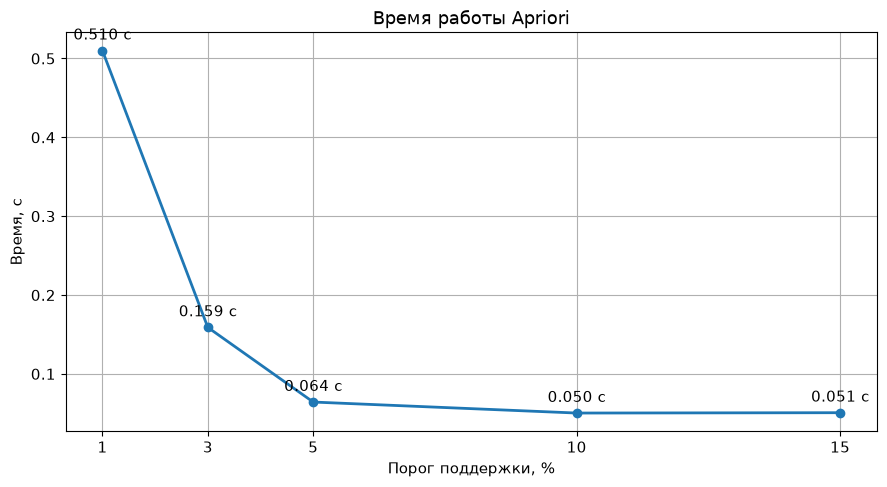

In [5]:
fig, ax = plt.subplots()
ax.plot(
    exp_df["min_support"] * 100,
    exp_df["время, с"],
    marker="o",
    linewidth=2,
)
ax.set_title("Время работы Apriori")
ax.set_xlabel("Порог поддержки, %")
ax.set_ylabel("Время, с")
ax.set_xticks(exp_df["min_support"] * 100)
for x, y in zip(exp_df["min_support"] * 100, exp_df["время, с"]):
    ax.annotate(f"{y:.3f} с", (x, y), textcoords="offset points", xytext=(0, 8), ha="center")
fig.tight_layout()
plt.show()


### Число частых наборов разной длины при изменяемом пороге поддержки


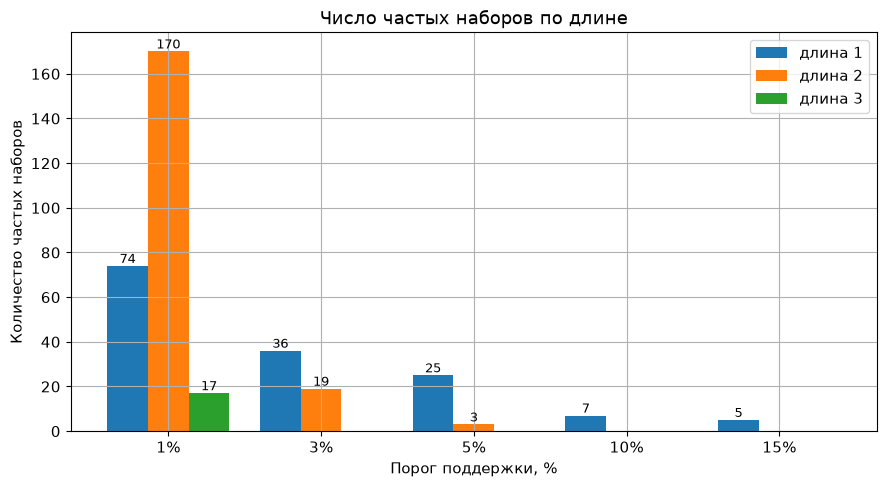

: 

In [6]:
pivot_plot = (
    len_df.pivot_table(
        index="min_support",
        columns="длина набора",
        values="количество",
        fill_value=0,
        aggfunc="sum",
    )
    .reindex(THRESHOLDS)
)

fig, ax = plt.subplots()
x = range(len(THRESHOLDS))
width = 0.8 / max(len(pivot_plot.columns), 1)

for i, length in enumerate(pivot_plot.columns):
    values = pivot_plot[length].to_numpy()
    positions = [p + (i - (len(pivot_plot.columns) - 1) / 2) * width for p in x]
    ax.bar(positions, values, width=width, label=f"длина {int(length)}")
    for pos, val in zip(positions, values):
        if val > 0:
            ax.text(pos, val, str(int(val)), ha="center", va="bottom", fontsize=9)

ax.set_title("Число частых наборов по длине")
ax.set_xlabel("Порог поддержки, %")
ax.set_ylabel("Количество частых наборов")
ax.set_xticks(list(x))
ax.set_xticklabels([f"{t:.0%}" for t in THRESHOLDS])
ax.legend()
fig.tight_layout()
plt.show()


## Выводы

- При низком пороге поддержки (1%) частых наборов больше, среди них появляются пары и тройки, а перебор кандидатов занимает больше времени.
- При повышении порога (10–15%) остаются в основном одиночные популярные товары, число наборов резко падает, алгоритм отрабатывает быстрее: меньше $L_1$, меньше соединений и проходов по данным.
